# Arrehnius refitting

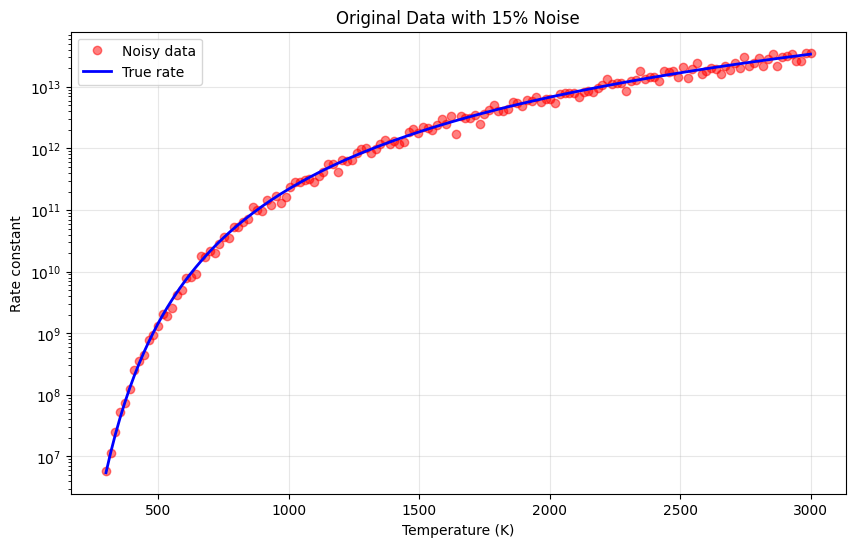

Parameter Comparison:
A  -> True: 5.08000e+04, Fitted: 2.29698e+04
n  -> True: 2.67000, Fitted: 2.76573
Ea -> True: 6.29200e+03, Fitted: 6.11657e+03

Fitting Statistics:
RSS: 3.14085e+00
DoF: 147


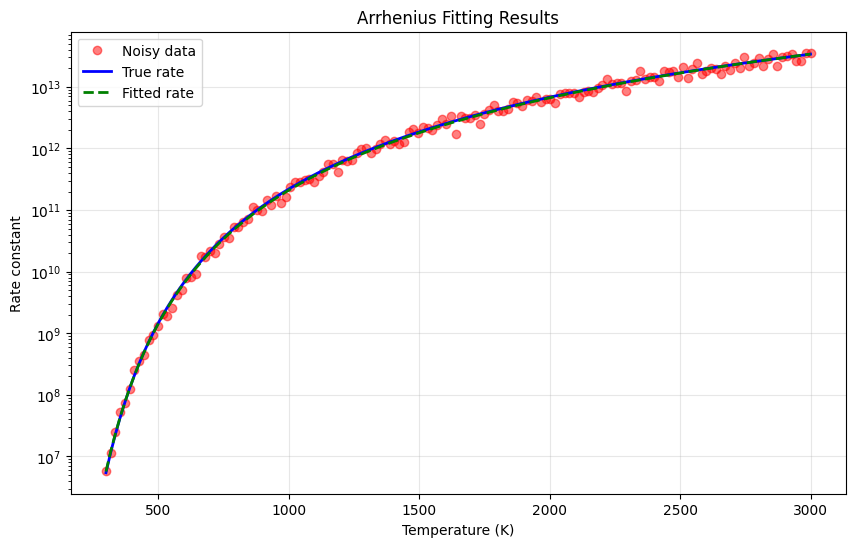

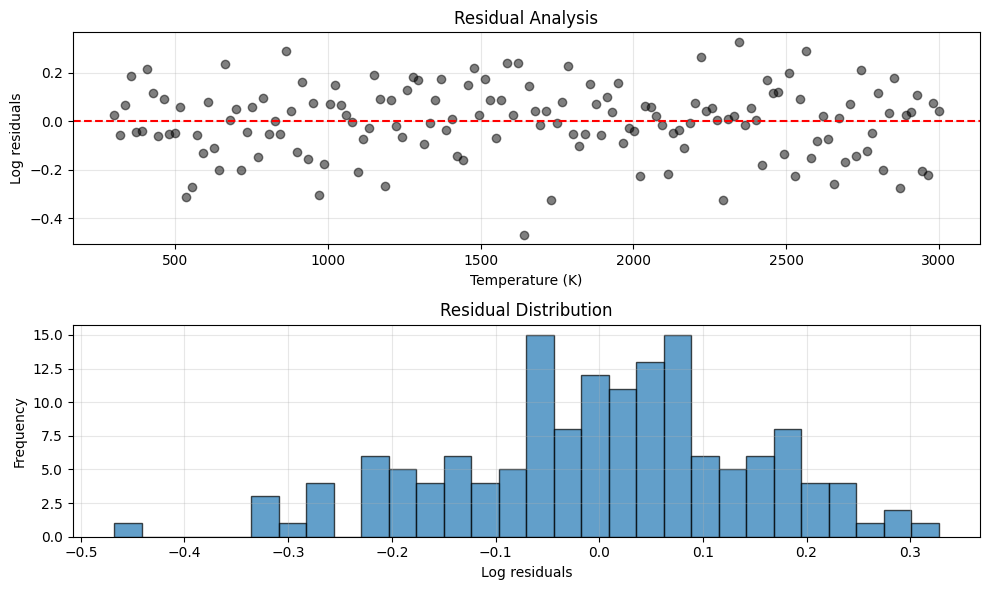

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from jax import lax, jit
import jax.numpy as jnp
from diffPLOG2TROE.parametrization import Arrhenius
from diffPLOG2TROE.utilities.physical_constants import constants

# --------------------------------------------------------
# Direct parameters initialization
rate_constant = Arrhenius(name="H2+O=H+OH", parameters=[5.080e+04, 2.670E+00, 6.292e+03])

# --------------------------------------------------------
# Generate the synthetic data
def simulate_rxn_data(noise_level=0.05, n_points=300):
    temperatures = jnp.linspace(300, 3000, n_points)
    rates = rate_constant.kinetic_constant(temperatures)
    
    # Add experimental noise (default 5% random error)
    np.random.seed(42)
    noisy_rates = rates * (1 + noise_level * np.random.randn(len(temperatures)))
    return temperatures, noisy_rates

# --------------------------------------------------------
# Helper function for applying weights
def apply_weights(X, y, weights):
    """Apply weights to design matrix and response vector for weighted least squares."""
    sqrt_weights = jnp.sqrt(weights)
    X_weighted = X * sqrt_weights[:, None]
    y_weighted = y * sqrt_weights
    return X_weighted, y_weighted

# --------------------------------------------------------
# Corrected refitting function
@jit
def refit_arrhenius(temperature, rate_constant_data, weights=None, three_params=True):
    log_k = jnp.log(rate_constant_data)
    inv_T = 1.0 / temperature
    
    # ==============================================================================
    # Build design matrix
    X = lax.cond(
        three_params,
        lambda _: jnp.vstack([jnp.ones_like(inv_T), jnp.log(temperature), -inv_T]).T,
        lambda _: jnp.vstack([jnp.ones_like(inv_T), jnp.zeros_like(inv_T), -inv_T]).T,
        None,
    )
    
    # ==============================================================================
    # Apply weights if provided
    weighted_fit = weights is not None
    if weighted_fit:
        X_weighted, y_weighted = apply_weights(X, log_k, weights)
    else:
        X_weighted, y_weighted = X, log_k
    
    # ==============================================================================
    # Perform least squares fit
    beta = jnp.linalg.lstsq(X_weighted, y_weighted, rcond=None)[0]
    
    # ==============================================================================
    # Calculate residuals and covariance matrix
    y_pred = X @ beta
    residuals = log_k - y_pred
    
    # ==============================================================================
    # Handle weighted residuals for RSS calculation
    if weighted_fit:
        rss = jnp.sum(weights * residuals**2)
    else:
        rss = jnp.sum(residuals**2)
    
    n_params = lax.cond(three_params, lambda _: 3, lambda _: 2, None)
    dof = len(rate_constant_data) - n_params
    
    # ==============================================================================
    # Covariance matrix calculation
    XTX_inv = jnp.linalg.inv(X_weighted.T @ X_weighted)
    
    # ==============================================================================
    # Mean squared error
    mse = rss / dof
    
    # ==============================================================================
    # Parameter covariance matrix
    cov_matrix = mse * XTX_inv
    
    # ==============================================================================
    # Standard errors (diagonal elements of covariance matrix)
    param_uncertainties = jnp.sqrt(jnp.diag(cov_matrix))
    
    # ==============================================================================
    # Handle two-parameter case by padding with zeros
    lnA_unc, n_unc, EaR_unc = lax.cond(
        three_params,
        lambda _: (param_uncertainties[0], param_uncertainties[1], param_uncertainties[2]),
        lambda _: (param_uncertainties[0], 0.0, param_uncertainties[1]),
        None,
    )
    
    return {
        "A": jnp.exp(beta[0]),
        "n": beta[1],
        "Ea": beta[2] * constants.R_cal_mol,
        "lnA_uncertainty": lnA_unc,
        "n_uncertainty": n_unc,
        "EaR_uncertainty": EaR_unc,
        "RSS": rss,
        "DoF": dof,
    }

# --------------------------------------------------------
# Generate experimental data with 15% noise
temperatures_data, rate_data = simulate_rxn_data(noise_level=0.15, n_points=150)
true_rate = rate_constant.kinetic_constant(temperatures_data)

# Plot original data
plt.figure(figsize=(10, 6))
plt.semilogy(temperatures_data, rate_data, "ro", alpha=0.5, label="Noisy data")
plt.semilogy(temperatures_data, true_rate, "b-", linewidth=2, label="True rate")
plt.xlabel("Temperature (K)")
plt.ylabel("Rate constant")
plt.legend()
plt.title("Original Data with 15% Noise")
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------------
# Perform the fitting
fitting_results = refit_arrhenius(temperatures_data, rate_data)
fitted_rate = Arrhenius(name="H2+O=H+OH", parameters=[fitting_results["A"], fitting_results["n"], fitting_results["Ea"]])
fitted_constant = fitted_rate.kinetic_constant(temperatures_data)

# Print results
print("Parameter Comparison:")
print(f"A  -> True: {jnp.exp(rate_constant.lnA):.5e}, Fitted: {fitting_results['A']:.5e}")
print(f"n  -> True: {rate_constant.n:.5f}, Fitted: {fitting_results['n']:.5f}")
print(f"Ea -> True: {rate_constant.EaR * constants.R_cal_mol:.5e}, Fitted: {fitting_results['Ea']:.5e}")
print(f"\nFitting Statistics:")
print(f"RSS: {fitting_results['RSS']:.5e}")
print(f"DoF: {fitting_results['DoF']}")

# Plot comparison
plt.figure(figsize=(10, 6))
plt.semilogy(temperatures_data, rate_data, "ro", alpha=0.5, label="Noisy data")
plt.semilogy(temperatures_data, true_rate, "b-", linewidth=2, label="True rate")
plt.semilogy(temperatures_data, fitted_constant, "g--", linewidth=2, label="Fitted rate")
plt.xlabel("Temperature (K)")
plt.ylabel("Rate constant")
plt.legend()
plt.title("Arrhenius Fitting Results")
plt.grid(True, alpha=0.3)
plt.show()

# --------------------------------------------------------
# Additional analysis: plot residuals
plt.figure(figsize=(10, 6))
residuals = jnp.log(rate_data) - jnp.log(fitted_constant)
plt.subplot(2, 1, 1)
plt.plot(temperatures_data, residuals, 'ko', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Temperature (K)")
plt.ylabel("Log residuals")
plt.title("Residual Analysis")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Log residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Results for 5% noise level:
Parameter  True Value   Fitted Value   95% CI
------------------------------------------------------------
A:         5.080e+04  3.930e+04  [2.803e+04, 5.510e+04]
n:         2.670        2.701        [2.659, 2.743]
Ea:        6292       6235       [6157, 6313]

R² = 0.999826
RMSE = 0.0474

Results for 10% noise level:
Parameter  True Value   Fitted Value   95% CI
------------------------------------------------------------
A:         5.080e+04  3.021e+04  [1.525e+04, 5.984e+04]
n:         2.670        2.733        [2.648, 2.818]
Ea:        6292       6177       [6019, 6335]

R² = 0.999289
RMSE = 0.0958

Results for 15% noise level:
Parameter  True Value   Fitted Value   95% CI
------------------------------------------------------------
A:         5.080e+04  2.297e+04  [8.094e+03, 6.519e+04]
n:         2.670        2.766        [2.636, 2.896]
Ea:        6292       6117       [5875, 6358]

R² = 0.998346
RMSE = 0.1462


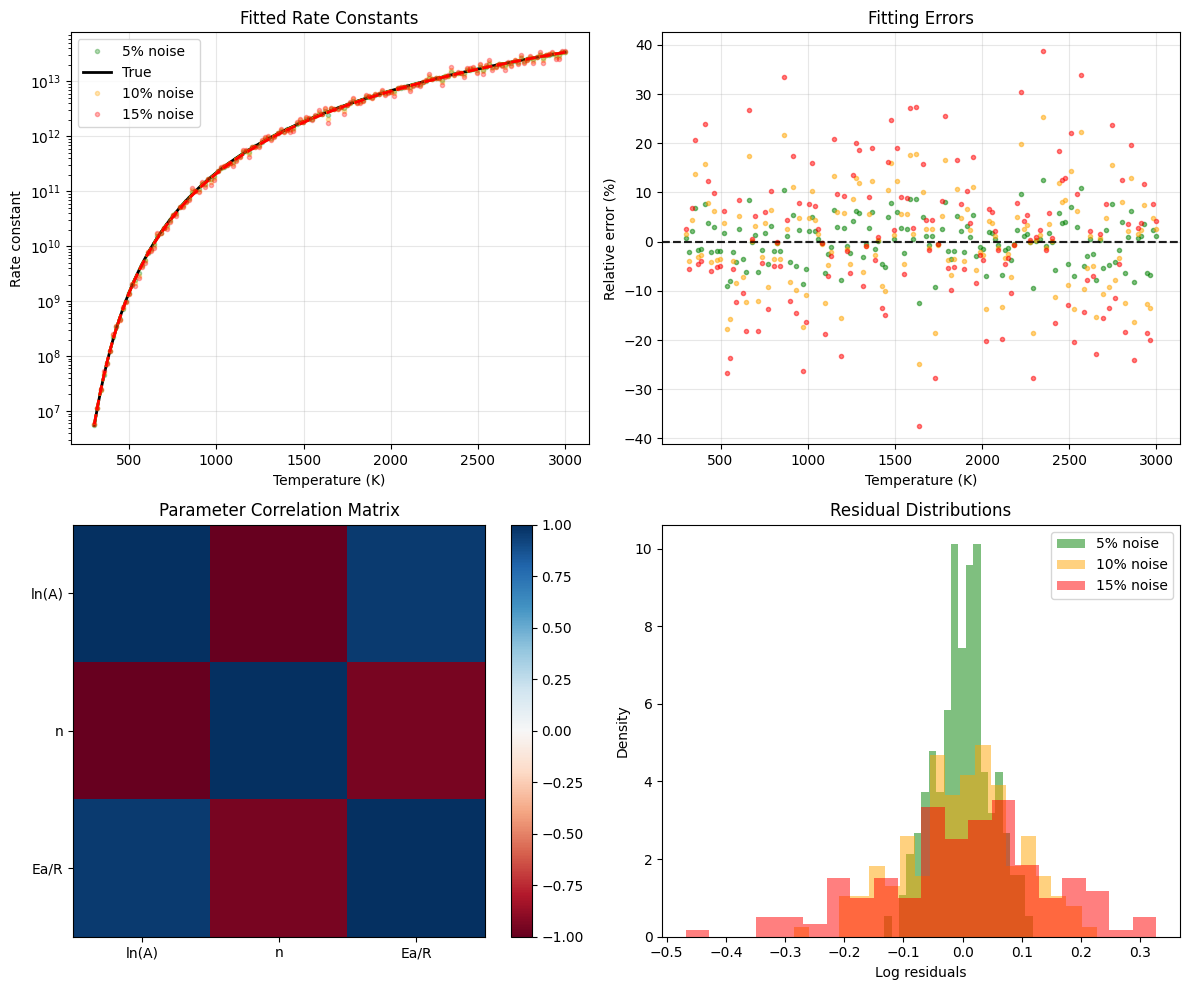



Bootstrap Uncertainty Analysis (15% noise):
A:  2.581e+04 ± 1.245e+04
n:  2.765 ± 0.059
Ea: 6120 ± 110


In [56]:
import matplotlib.pyplot as plt
import numpy as np
from jax import lax, jit
import jax.numpy as jnp
from diffPLOG2TROE.parametrization import Arrhenius
from diffPLOG2TROE.utilities.physical_constants import constants

# --------------------------------------------------------
# Direct parameters initialization
rate_constant = Arrhenius(name="H2+O=H+OH", parameters=[5.080e+04, 2.670E+00, 6.292e+03])

# Generate the synthetic data
def simulate_rxn_data(noise_level=0.05, n_points=300):
    temperatures = jnp.linspace(300, 3000, n_points)
    rates = rate_constant.kinetic_constant(temperatures)
    
    # Add experimental noise (default 5% random error)
    np.random.seed(42)
    noisy_rates = rates * (1 + noise_level * np.random.randn(len(temperatures)))
    return temperatures, noisy_rates

# Helper function for applying weights
def apply_weights(X, y, weights):
    """Apply weights to design matrix and response vector for weighted least squares."""
    sqrt_weights = jnp.sqrt(weights)
    X_weighted = X * sqrt_weights[:, None]
    y_weighted = y * sqrt_weights
    return X_weighted, y_weighted

# Enhanced refitting function with better diagnostics
@jit
def refit_arrhenius(temperature, rate_constant_data, weights=None, three_params=True):
    log_k = jnp.log(rate_constant_data)
    inv_T = 1.0 / temperature
    
    # Build design matrix
    X = lax.cond(
        three_params,
        lambda _: jnp.vstack([jnp.ones_like(inv_T), jnp.log(temperature), -inv_T]).T,
        lambda _: jnp.vstack([jnp.ones_like(inv_T), jnp.zeros_like(inv_T), -inv_T]).T,
        None,
    )
    
    # Apply weights if provided
    weighted_fit = weights is not None
    if weighted_fit:
        X_weighted, y_weighted = apply_weights(X, log_k, weights)
    else:
        X_weighted, y_weighted = X, log_k
    
    # Perform least squares fit
    beta = jnp.linalg.lstsq(X_weighted, y_weighted, rcond=None)[0]
    
    # Calculate residuals and covariance matrix
    y_pred = X @ beta
    residuals = log_k - y_pred
    
    # Handle weighted residuals for RSS calculation
    if weighted_fit:
        rss = jnp.sum(weights * residuals**2)
    else:
        rss = jnp.sum(residuals**2)
    
    n_params = lax.cond(three_params, lambda _: 3, lambda _: 2, None)
    dof = len(rate_constant_data) - n_params
    
    # Covariance matrix calculation
    XTX_inv = jnp.linalg.inv(X_weighted.T @ X_weighted)
    
    # Mean squared error
    mse = rss / dof
    
    # Parameter covariance matrix
    cov_matrix = mse * XTX_inv
    
    # Standard errors (diagonal elements of covariance matrix)
    param_uncertainties = jnp.sqrt(jnp.diag(cov_matrix))
    
    # Handle two-parameter case by padding with zeros
    lnA_unc, n_unc, EaR_unc = lax.cond(
        three_params,
        lambda _: (param_uncertainties[0], param_uncertainties[1], param_uncertainties[2]),
        lambda _: (param_uncertainties[0], 0.0, param_uncertainties[1]),
        None,
    )
    
    # Calculate R-squared
    ss_tot = jnp.sum((log_k - jnp.mean(log_k))**2)
    r_squared = 1 - (rss / ss_tot)
    
    return {
        "A": jnp.exp(beta[0]),
        "n": beta[1],
        "Ea": beta[2] * constants.R_cal_mol,
        "lnA_uncertainty": lnA_unc,
        "n_uncertainty": n_unc,
        "EaR_uncertainty": EaR_unc,
        "Ea_uncertainty": EaR_unc * constants.R_cal_mol,
        "RSS": rss,
        "DoF": dof,
        "MSE": mse,
        "R_squared": r_squared,
        "residuals": residuals,
        "cov_matrix": cov_matrix
    }

# --------------------------------------------------------
# Function to compute confidence intervals
def compute_confidence_intervals(fitting_results, confidence_level=0.95):
    """Compute confidence intervals for the fitted parameters."""
    from scipy import stats
    
    # t-value for given confidence level
    t_value = stats.t.ppf((1 + confidence_level) / 2, fitting_results["DoF"])
    
    # Confidence intervals
    A_CI = fitting_results["A"] * jnp.exp(jnp.array([-t_value, t_value]) * fitting_results["lnA_uncertainty"])
    n_CI = fitting_results["n"] + jnp.array([-t_value, t_value]) * fitting_results["n_uncertainty"]
    Ea_CI = fitting_results["Ea"] + jnp.array([-t_value, t_value]) * fitting_results["Ea_uncertainty"]
    
    return {"A_CI": A_CI, "n_CI": n_CI, "Ea_CI": Ea_CI}

# --------------------------------------------------------
# Run analysis with different noise levels
noise_levels = [0.05, 0.10, 0.15]
colors = ['green', 'orange', 'red']
n_points = 150

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (noise, color) in enumerate(zip(noise_levels, colors)):
    # Generate data
    temps, rates = simulate_rxn_data(noise_level=noise, n_points=n_points)
    true_rates = rate_constant.kinetic_constant(temps)
    
    # Fit the data
    results = refit_arrhenius(temps, rates)
    fitted_arrhenius = Arrhenius(name="Fitted", parameters=[results["A"], results["n"], results["Ea"]])
    fitted_rates = fitted_arrhenius.kinetic_constant(temps)
    
    # Compute confidence intervals
    ci = compute_confidence_intervals(results)
    
    # Plot 1: Rate constants
    ax = axes[0, 0]
    ax.semilogy(temps, rates, 'o', color=color, alpha=0.3, markersize=3, label=f'{int(noise*100)}% noise')
    ax.semilogy(temps, fitted_rates, '--', color=color, linewidth=2)
    if i == 0:
        ax.semilogy(temps, true_rates, 'k-', linewidth=2, label='True')
    
    # Plot 2: Relative errors
    ax = axes[0, 1]
    rel_error = (rates - fitted_rates) / fitted_rates * 100
    ax.plot(temps, rel_error, 'o', color=color, alpha=0.5, markersize=3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Results for {int(noise*100)}% noise level:")
    print(f"{'='*60}")
    print(f"Parameter  True Value   Fitted Value   95% CI")
    print(f"-"*60)
    print(f"A:         {jnp.exp(rate_constant.lnA):.3e}  {results['A']:.3e}  [{ci['A_CI'][0]:.3e}, {ci['A_CI'][1]:.3e}]")
    print(f"n:         {rate_constant.n:.3f}        {results['n']:.3f}        [{ci['n_CI'][0]:.3f}, {ci['n_CI'][1]:.3f}]")
    print(f"Ea:        {rate_constant.EaR * constants.R_cal_mol:.0f}       {results['Ea']:.0f}       [{ci['Ea_CI'][0]:.0f}, {ci['Ea_CI'][1]:.0f}]")
    print(f"\nR² = {results['R_squared']:.6f}")
    print(f"RMSE = {jnp.sqrt(results['MSE']):.4f}")

# --------------------------------------------------------
# Plot 3: Parameter correlations
ax = axes[1, 0]
# Use the last results for correlation plot
cov = results['cov_matrix']
corr = cov / jnp.sqrt(jnp.diag(cov)[:, None] * jnp.diag(cov)[None, :])
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['ln(A)', 'n', 'Ea/R'])
ax.set_yticklabels(['ln(A)', 'n', 'Ea/R'])
ax.set_title('Parameter Correlation Matrix')
plt.colorbar(im, ax=ax)

# --------------------------------------------------------
# Plot 4: Residual distribution
ax = axes[1, 1]
for i, (noise, color, results) in enumerate(zip(noise_levels, colors, 
    [refit_arrhenius(simulate_rxn_data(noise_level=n, n_points=n_points)[0], 
                     simulate_rxn_data(noise_level=n, n_points=n_points)[1]) 
     for n in noise_levels])):
    ax.hist(results['residuals'], bins=20, alpha=0.5, color=color, 
            label=f'{int(noise*100)}% noise', density=True)
ax.set_xlabel('Log residuals')
ax.set_ylabel('Density')
ax.set_title('Residual Distributions')
ax.legend()

# --------------------------------------------------------
# Configure axes
axes[0, 0].set_xlabel('Temperature (K)')
axes[0, 0].set_ylabel('Rate constant')
axes[0, 0].set_title('Fitted Rate Constants')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_xlabel('Temperature (K)')
axes[0, 1].set_ylabel('Relative error (%)')
axes[0, 1].set_title('Fitting Errors')
axes[0, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------------
# Bootstrap uncertainty estimation
def bootstrap_uncertainty(temperatures, rates, n_bootstrap=100):
    """Estimate parameter uncertainties using bootstrap resampling."""
    n_points = len(temperatures)
    bootstrap_params = []
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n_points, n_points, replace=True)
        temp_boot = temperatures[indices]
        rate_boot = rates[indices]
        
        # Fit to bootstrap sample
        results_boot = refit_arrhenius(temp_boot, rate_boot)
        bootstrap_params.append([results_boot["A"], results_boot["n"], results_boot["Ea"]])
    
    bootstrap_params = jnp.array(bootstrap_params)
    
    # Calculate statistics
    param_means = jnp.mean(bootstrap_params, axis=0)
    param_stds = jnp.std(bootstrap_params, axis=0)
    
    # Convert percentile values to JAX array
    param_percentiles = jnp.percentile(bootstrap_params, jnp.array([2.5, 97.5]), axis=0)
    
    return {
        "means": param_means,
        "stds": param_stds,
        "percentiles_2.5": param_percentiles[0],
        "percentiles_97.5": param_percentiles[1]
    }

# Example bootstrap analysis (optional)
print("\n\nBootstrap Uncertainty Analysis (15% noise):")
temps, rates = simulate_rxn_data(noise_level=0.15, n_points=150)
bootstrap_results = bootstrap_uncertainty(temps, rates, n_bootstrap=100)
print(f"A:  {bootstrap_results['means'][0]:.3e} ± {bootstrap_results['stds'][0]:.3e}")
print(f"n:  {bootstrap_results['means'][1]:.3f} ± {bootstrap_results['stds'][1]:.3f}")
print(f"Ea: {bootstrap_results['means'][2]:.0f} ± {bootstrap_results['stds'][2]:.0f}")

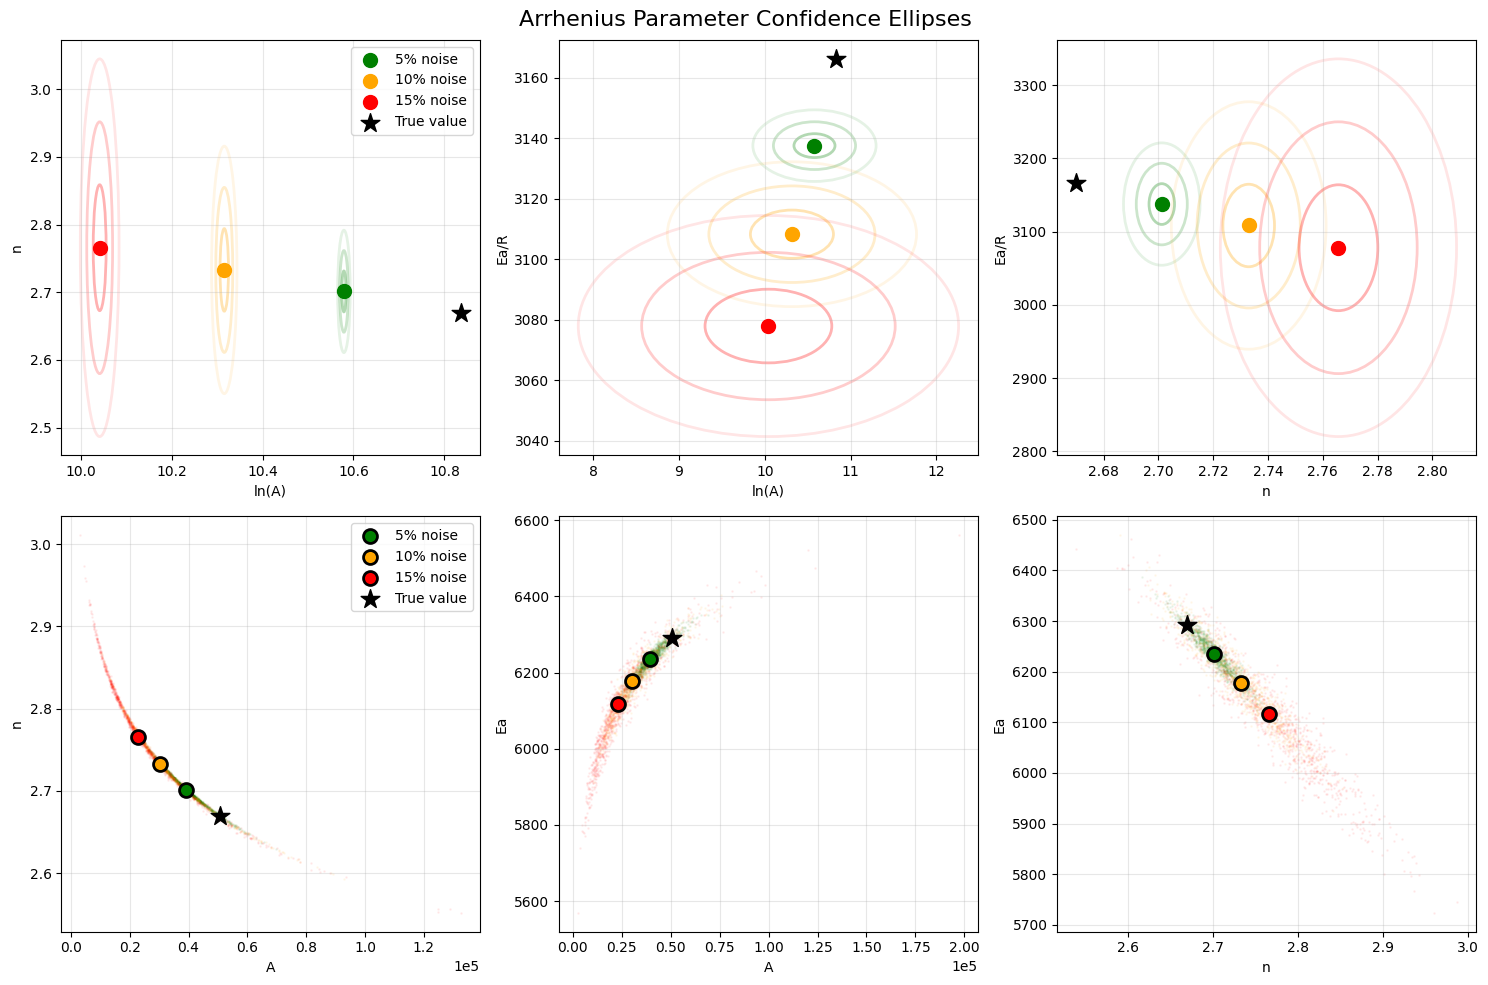

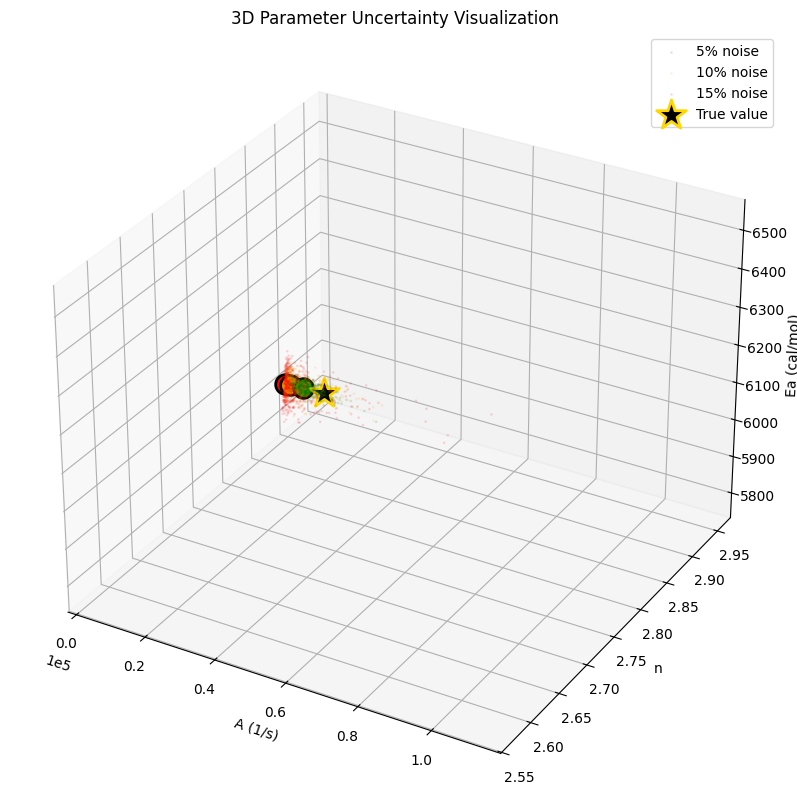

Ellipse interpretation:
- Each ellipse represents a confidence region (1σ, 2σ, 3σ)
- The shape shows parameter correlation
- Narrow ellipses indicate strong correlation
- The tilt indicates positive or negative correlation


In [57]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from jax import lax, jit
import jax.numpy as jnp
from diffPLOG2TROE.parametrization import Arrhenius
from diffPLOG2TROE.utilities.physical_constants import constants
from scipy import stats

# --------------------------------------------------------
# Functions from previous code (needed for this to run)
# --------------------------------------------------------
# Direct parameters initialization
rate_constant = Arrhenius(name="H2+O=H+OH", parameters=[5.080e+04, 2.670E+00, 6.292e+03])

def simulate_rxn_data(noise_level=0.05, n_points=300):
    temperatures = jnp.linspace(300, 3000, n_points)
    rates = rate_constant.kinetic_constant(temperatures)
    np.random.seed(42)
    noisy_rates = rates * (1 + noise_level * np.random.randn(len(temperatures)))
    return temperatures, noisy_rates

def apply_weights(X, y, weights):
    sqrt_weights = jnp.sqrt(weights)
    X_weighted = X * sqrt_weights[:, None]
    y_weighted = y * sqrt_weights
    return X_weighted, y_weighted

@jit
def refit_arrhenius(temperature, rate_constant_data, weights=None, three_params=True):
    log_k = jnp.log(rate_constant_data)
    inv_T = 1.0 / temperature
    
    X = lax.cond(
        three_params,
        lambda _: jnp.vstack([jnp.ones_like(inv_T), jnp.log(temperature), -inv_T]).T,
        lambda _: jnp.vstack([jnp.ones_like(inv_T), jnp.zeros_like(inv_T), -inv_T]).T,
        None,
    )
    
    weighted_fit = weights is not None
    if weighted_fit:
        X_weighted, y_weighted = apply_weights(X, log_k, weights)
    else:
        X_weighted, y_weighted = X, log_k
    
    beta = jnp.linalg.lstsq(X_weighted, y_weighted, rcond=None)[0]
    
    y_pred = X @ beta
    residuals = log_k - y_pred
    
    if weighted_fit:
        rss = jnp.sum(weights * residuals**2)
    else:
        rss = jnp.sum(residuals**2)
    
    n_params = lax.cond(three_params, lambda _: 3, lambda _: 2, None)
    dof = len(rate_constant_data) - n_params
    
    XTX_inv = jnp.linalg.inv(X_weighted.T @ X_weighted)
    mse = rss / dof
    cov_matrix = mse * XTX_inv
    param_uncertainties = jnp.sqrt(jnp.diag(cov_matrix))
    
    lnA_unc, n_unc, EaR_unc = lax.cond(
        three_params,
        lambda _: (param_uncertainties[0], param_uncertainties[1], param_uncertainties[2]),
        lambda _: (param_uncertainties[0], 0.0, param_uncertainties[1]),
        None,
    )
    
    ss_tot = jnp.sum((log_k - jnp.mean(log_k))**2)
    r_squared = 1 - (rss / ss_tot)
    
    return {
        "A": jnp.exp(beta[0]),
        "n": beta[1],
        "Ea": beta[2] * constants.R_cal_mol,
        "beta": beta,  # Store raw parameters
        "lnA_uncertainty": lnA_unc,
        "n_uncertainty": n_unc,
        "EaR_uncertainty": EaR_unc,
        "Ea_uncertainty": EaR_unc * constants.R_cal_mol,
        "RSS": rss,
        "DoF": dof,
        "MSE": mse,
        "R_squared": r_squared,
        "residuals": residuals,
        "cov_matrix": cov_matrix
    }

# --------------------------------------------------------
# Function to create confidence ellipse
# --------------------------------------------------------
def confidence_ellipse(cov, mean_x, mean_y, ax, n_std=2.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.
    
    Parameters
    ----------
    cov : 2x2 covariance matrix
    mean_x, mean_y : x and y means
    ax : matplotlib.axes.Axes
    n_std : number of standard deviations for the ellipse radius
    facecolor : color to use for filling
    **kwargs : forwarded to Ellipse patch
    
    Returns
    -------
    matplotlib.patches.Ellipse
    """
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    
    # Using a special case to obtain the eigenvalues of this two-dimensional dataset
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    
    # Calculating the standard deviation of x and y from the covariance matrix
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    
    transf = transforms.Affine2D() \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# --------------------------------------------------------
# Generate data and perform fitting
# --------------------------------------------------------
noise_levels = [0.05, 0.10, 0.15]
colors = ['green', 'orange', 'red']
n_points = 150

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Arrhenius Parameter Confidence Ellipses', fontsize=16)

# Store results for all noise levels
all_results = []
for noise in noise_levels:
    temps, rates = simulate_rxn_data(noise_level=noise, n_points=n_points)
    results = refit_arrhenius(temps, rates)
    all_results.append(results)

# True parameter values
true_lnA = rate_constant.lnA
true_n = rate_constant.n
true_EaR = rate_constant.EaR
true_A = jnp.exp(true_lnA)
true_Ea = true_EaR * constants.R_cal_mol

# Plot parameter pairs with confidence ellipses
parameter_pairs = [
    (0, 1, 'ln(A)', 'n'),
    (0, 2, 'ln(A)', 'Ea/R'),
    (1, 2, 'n', 'Ea/R')
]

for col, (i, j, xlabel, ylabel) in enumerate(parameter_pairs):
    ax = axes[0, col]
    
    for noise, color, results in zip(noise_levels, colors, all_results):
        # Extract covariance for the parameter pair
        cov_pair = results['cov_matrix'][np.ix_([i, j], [i, j])]
        
        # Get fitted parameters
        if i == 0:
            mean_i = results['beta'][0]  # ln(A)
        elif i == 1:
            mean_i = results['n']
        else:
            mean_i = results['beta'][2]  # Ea/R
            
        if j == 1:
            mean_j = results['n']
        else:
            mean_j = results['beta'][2]  # Ea/R
        
        # Plot confidence ellipses for different confidence levels
        for n_std, alpha in [(1, 0.3), (2, 0.2), (3, 0.1)]:
            confidence_ellipse(cov_pair, mean_i, mean_j, ax, n_std=n_std,
                             edgecolor=color, alpha=alpha, linewidth=2)
        
        # Plot fitted point
        ax.scatter(mean_i, mean_j, color=color, s=100, zorder=5,
                  label=f'{int(noise*100)}% noise')
    
    # Plot true values
    if i == 0:
        true_i = true_lnA
    elif i == 1:
        true_i = true_n
    else:
        true_i = true_EaR
        
    if j == 1:
        true_j = true_n
    else:
        true_j = true_EaR
        
    ax.scatter(true_i, true_j, color='black', marker='*', s=200, zorder=6,
              label='True value')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend()

# Convert to physical units for bottom row
parameter_pairs_physical = [
    ('A', 'n'),
    ('A', 'Ea'),
    ('n', 'Ea')
]

for col, (param1, param2) in enumerate(parameter_pairs_physical):
    ax = axes[1, col]
    
    # Bootstrap samples for visualization
    n_samples = 1000
    for noise, color, results in zip(noise_levels, colors, all_results):
        # Generate samples from multivariate normal
        mean = results['beta']
        cov = results['cov_matrix']
        samples = np.random.multivariate_normal(mean, cov, n_samples)
        
        # Transform to physical parameters
        if param1 == 'A':
            x_samples = np.exp(samples[:, 0])
            x_center = results['A']
        elif param1 == 'n':
            x_samples = samples[:, 1]
            x_center = results['n']
        else:  # Ea
            x_samples = samples[:, 2] * constants.R_cal_mol
            x_center = results['Ea']
            
        if param2 == 'n':
            y_samples = samples[:, 1]
            y_center = results['n']
        elif param2 == 'Ea':
            y_samples = samples[:, 2] * constants.R_cal_mol
            y_center = results['Ea']
        else:  # A
            y_samples = np.exp(samples[:, 0])
            y_center = results['A']
        
        # Plot samples as scatter
        ax.scatter(x_samples, y_samples, alpha=0.05, color=color, s=1)
        
        # Plot center point
        ax.scatter(x_center, y_center, color=color, s=100, edgecolor='black',
                  linewidth=2, zorder=5, label=f'{int(noise*100)}% noise')
    
    # Plot true values
    if param1 == 'A':
        true_x = true_A
    elif param1 == 'n':
        true_x = true_n
    else:
        true_x = true_Ea
        
    if param2 == 'n':
        true_y = true_n
    elif param2 == 'Ea':
        true_y = true_Ea
    else:
        true_y = true_A
        
    ax.scatter(true_x, true_y, color='black', marker='*', s=200, zorder=6,
              label='True value')
    
    ax.set_xlabel(param1)
    ax.set_ylabel(param2)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.legend()
    
    # Use scientific notation for A
    if param1 == 'A':
        ax.ticklabel_format(axis='x', style='scientific', scilimits=(0,0))
    if param2 == 'A':
        ax.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 3D visualization of parameter space
# --------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Generate samples for 3D visualization
n_samples = 500
for noise, color, results in zip(noise_levels, colors, all_results):
    mean = results['beta']
    cov = results['cov_matrix']
    samples = np.random.multivariate_normal(mean, cov, n_samples)
    
    # Transform to physical parameters
    A_samples = np.exp(samples[:, 0])
    n_samples_param = samples[:, 1]
    Ea_samples = samples[:, 2] * constants.R_cal_mol
    
    ax.scatter(A_samples, n_samples_param, Ea_samples, 
              alpha=0.1, color=color, s=1, label=f'{int(noise*100)}% noise')

# Plot true value
ax.scatter(true_A, true_n, true_Ea, color='black', marker='*', s=500, 
          label='True value', edgecolor='gold', linewidth=2)

# Plot fitted centers
for noise, color, results in zip(noise_levels, colors, all_results):
    ax.scatter(results['A'], results['n'], results['Ea'], 
              color=color, s=200, edgecolor='black', linewidth=2)

ax.set_xlabel('A (1/s)')
ax.set_ylabel('n')
ax.set_zlabel('Ea (cal/mol)')
ax.set_title('3D Parameter Uncertainty Visualization')
ax.legend()

# Format A axis
ax.ticklabel_format(axis='x', style='scientific', scilimits=(0,0))

plt.show()